<a href="https://colab.research.google.com/github/zhouqiang06/ADVISE/blob/main/Demo_of_analysis_biomass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biomass model for Euroasia
This notebook demonstrates an example of using the ADVISE framework to derive a new model for estimating aboveground biomass (AGB) from tree height and diameter at breast height (DBH).

## 1. Environment Setup & Dependencies

In [1]:
# Install optimization and interpretability frameworks
!pip install optuna pysr #captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.0 MB/s eta 0:00:00


In [2]:
import os
import sys
from glob import glob
from datetime import datetime

import numpy as np
import pandas as pd
from sklearn import preprocessing
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# from pysr import PySRRegressor

import torch
import torch.nn as nn
import torch.optim as optim

import time
import json
import joblib

## 2. Global Configuration Variables

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

####  Data are from   ###
####  DOI:    ###
####  We use most of the Eruope measurement for the model training and the rest data for validation   ###

# DATA_PATH = './Biomass_tree_DB_2var.csv'
DATA_PATH = '/content/drive/My Drive/Colab Notebooks/Biomass_tree_DB_2var_model.csv'
VALID_PATH = '/content/drive/My Drive/Colab Notebooks/Biomass_tree_DB_2var_validation.csv'
N_VAR = 2 # number of X variables

# SAVE_PATH = './outputs'
SAVE_PATH = '/content/drive/My Drive/Colab Notebooks/Biomass_outputs'
os.makedirs(SAVE_PATH, exist_ok=True)

In [14]:
import folium

# Load your files (replace with actual filenames)
df1 = pd.read_csv(DATA_PATH)
df2 = pd.read_csv(VALID_PATH)


# Create a map centered at the average location
center_lat = pd.concat([df1['Latitude'], df2['Latitude']]).mean()
center_lon = pd.concat([df1['Longitude'], df2['Longitude']]).mean()


# Create a Figure that defines the actual display size (not just the map canvas)
fig = folium.Figure(width=1200, height=600)

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=3,
    width=1200,
    height=600,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri — Source: Esri, DeLorme, NAVTEQ, USGS, Intermap and others"
)


# Plot points from the first CSV (blue)
for _, row in df1.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue'
    ).add_to(m)

# Plot points from the second CSV (red)
for _, row in df2.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='red',
        fill=True,
        fill_color='red'
    ).add_to(m)


# Add legend as HTML overlay
legend_html = '''
<div style="
    position: fixed;
    top: 10px;
    left: 10px;
    width: 160px;
    height: 100px;
    border: 2px solid grey;
    background-color: white;
    z-index: 9999;
    font-size: 14px;
    padding: 10px;
    opacity: 0.95;">
<strong>Legend</strong><br>
<span style="color: blue; font-size: 20px;">●</span> Validation<br>
<span style="color: red; font-size: 20px;">●</span> Training<br>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))


# Attach the map to the figure (this fixes the giant output window problem)
fig.add_child(m)

fig

## 3. Data Preprocessing

In [ ]:
def preprocessing_data(dataset, standerize=True, train_portion=0.8, min_train=3000):
  """Shuffles, splits, and standardizes feature vectors into train and test spaces.

  Args:
      dataset (array): orginal data
      standerize (bool, optional): If standerize X variables. Defaults to True.
      train_portion (float, optional): split training test data. Defaults to 0.8.

  Returns:
      train_x (array): Preprocessed X training data
      train_y (array): Preprocessed Y training data
      test_x (array): Preprocessed X test data
      test_y (array): Preprocessed Y test data
      scaler (object): The standardization scaler (see sklearn.preprocessing.StandardScaler)
  """
  # preview_simudata(dataset)
  # Make sure the last column is y
  dataset = dataset.reset_index(drop=True)
  shuf_idx = dataset.sample(frac=1).index  # Shuffle index of dataframe
  # print('idx:', np.min(shuf_idx), np.max(shuf_idx), len(dataset))
  full_feature = dataset.iloc[shuf_idx]  # Shuffle dataframe
  np.save(os.path.join(SAVE_PATH, 'simu_shuf_idx.npy'), shuf_idx)
  full_feature.iloc[:, :-1].to_csv(os.path.join(SAVE_PATH, 'all_fea_raw.csv'), index=False)
  # full_feature = dataset
  n_training = max(int(len(full_feature) * train_portion), min_train)

  if standerize:
    x_stack = full_feature.iloc[:, :-1].values.copy()  # returns a numpy array
    scaler = preprocessing.StandardScaler()
    x_scaled = scaler.fit_transform(x_stack)
    full_feature.iloc[:, :-1] = x_scaled

  else:
    scaler = None

  dataset_x = full_feature.iloc[:, :-1].values.copy()
  dataset_y = full_feature.iloc[:, -1].values.copy()
  train_x = dataset_x[:n_training, :].copy()
  train_y = dataset_y[:n_training].copy()

  test_x = dataset_x[n_training:, :].copy()
  test_y = dataset_y[n_training:].copy()
  return train_x, train_y, test_x, test_y, scaler

In [ ]:
# Execute data preprocessing pipeline
dataset = pd.read_csv(DATA_PATH)
dataset = dataset[["DBH", "H_tree", "Pabo"]]
var_names = list(dataset.columns)
train_x_np, train_y_np, test_x_np, test_y_np, scaler = preprocessing_data(
    dataset, standerize=True, train_portion=0.8
)

# Stack arrays and serialize datasets
all_fea_np = np.vstack((train_x_np, test_x_np))
y_fea_np = np.vstack((train_y_np[:, np.newaxis], test_y_np[:, np.newaxis]))
np.save(os.path.join(SAVE_PATH, 'all_fea.npy'), all_fea_np)
np.save(os.path.join(SAVE_PATH, 'y_fea.npy'), y_fea_np)

if scaler is not None:
    all_fea_raw = scaler.inverse_transform(all_fea_np)
    np.save(os.path.join(SAVE_PATH, 'all_fea_raw.npy'), all_fea_raw)
    joblib.dump(scaler, os.path.join(SAVE_PATH, 'torch_scaler.bin'))

# Construct PyTorch variables
train_x = torch.from_numpy(train_x_np).float()
train_y = torch.from_numpy(train_y_np).float().unsqueeze(1)
test_x = torch.from_numpy(test_x_np).float()
test_y = torch.from_numpy(test_y_np).float().unsqueeze(1)
all_fea = torch.from_numpy(all_fea_np).float()

## 4. Deep Neural Network Optimization & Training
Defines a dynamic network architecture evaluated dynamically across continuous trails using an Optuna Study.

In [ ]:
import optuna

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model=None):
        if self.best_loss is None:
            self.best_loss = val_loss
            if model is not None:
                self.best_model_state = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            if model is not None:
                self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0

class RegressionDNN(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Dynamically build hidden layers
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

def objective(trial):
    # Structural architecture search boundaries
    num_layers = trial.suggest_int("num_layers", 1, 10)

    hidden_dims = []
    for i in range(num_layers):
        units = trial.suggest_int(f"units_layer_{i}", 16, 512)
        hidden_dims.append(units)

    # Hyperparameter tuning variables
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # Data Setup
    train_ds = torch.utils.data.TensorDataset(train_x, train_y)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # Model & Optimization Setup
    model = RegressionDNN(input_dim=train_x.shape[1], hidden_dims=hidden_dims)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    # Initialize early stopping for the hyperparameter search trial
    early_stopping = EarlyStopping(patience=5)

    # Training Loop
    for epoch in range(30):
        model.train()
        for b_x, b_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(b_x), b_y)
            loss.backward()
            optimizer.step()

        # Evaluation Loop
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(test_x), test_y).item()

        # Optuna Pruning Check
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Local Trial Early Stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            break

    return early_stopping.best_loss


[I 2026-09-21 19:55:10,990] A new study created in memory with name: no-name-d767204d-6e9c-4f56-b8b1-d43b9f4f30cd
[I 2026-09-21 19:55:20,960] Trial 0 finished with value: 996.2333374023438 and parameters: {'num_layers': 9, 'units_layer_0': 390, 'units_layer_1': 47, 'units_layer_2': 378, 'units_layer_3': 143, 'units_layer_4': 149, 'units_layer_5': 362, 'units_layer_6': 160, 'units_layer_7': 189, 'units_layer_8': 321, 'lr': 0.0003220093255565711, 'batch_size': 64, 'weight_decay': 0.0002458052598149904}. Best is trial 0 with value: 996.2333374023438.
[I 2026-09-21 19:55:29,023] Trial 1 finished with value: 1032.56982421875 and parameters: {'num_layers': 5, 'units_layer_0': 326, 'units_layer_1': 405, 'units_layer_2': 396, 'units_layer_3': 501, 'units_layer_4': 353, 'lr': 0.00019526034571008, 'batch_size': 64, 'weight_decay': 2.441976839598561e-06}. Best is trial 0 with value: 996.2333374023438.
[I 2026-09-21 19:55:33,582] Trial 2 finished with value: 1020.155517578125 and parameters: {'num


Optimization Complete. Best Params: {'num_layers': 10, 'units_layer_0': 271, 'units_layer_1': 446, 'units_layer_2': 285, 'units_layer_3': 40, 'units_layer_4': 403, 'units_layer_5': 286, 'units_layer_6': 251, 'units_layer_7': 181, 'units_layer_8': 113, 'units_layer_9': 448, 'lr': 0.0005796267292249735, 'batch_size': 64, 'weight_decay': 1.3439353064982244e-05}


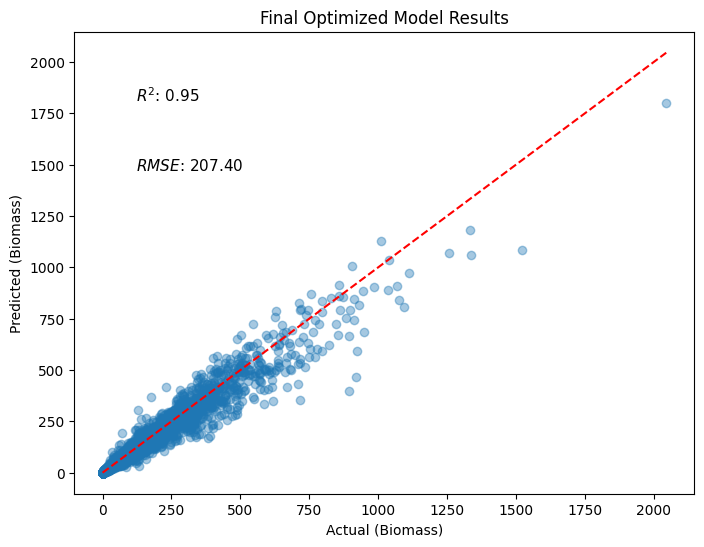

In [ ]:
# Execute Model Optimization Study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
best_params = study.best_trial.params
print(f"\nOptimization Complete. Best Params: {best_params}")

# Reconstruct the optimized architecture config
best_hidden_dims = []
num_layers = best_params["num_layers"]
for i in range(num_layers):
    best_hidden_dims.append(best_params[f"units_layer_{i}"])
final_model = RegressionDNN(input_dim=train_x.shape[1], hidden_dims=best_hidden_dims)
optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)
criterion = nn.MSELoss()
final_ds = torch.utils.data.TensorDataset(train_x, train_y)
final_loader = torch.utils.data.DataLoader(
    final_ds,
    batch_size=best_params["batch_size"],
    shuffle=True
)

# Final convergence execution phase
# final_model.train()
# Initialize early stopping for the final convergence model (with checkpointing capability)
final_early_stop = EarlyStopping(patience=10)
for epoch in range(100):
    for b_x, b_y in final_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(b_x), b_y)
        loss.backward()
        optimizer.step()

# Save optimized states along with network parameters
checkpoint = {
    'hidden_dims': best_hidden_dims,
    'state_dict': final_model.state_dict(),
    'scaler_param': best_params
}
torch.save(checkpoint, os.path.join(SAVE_PATH, 'final_regression_model.pt'))

# Performance predictions generation
final_model.eval()
input_data = all_fea.clone().detach().requires_grad_(True)
predictions = final_model(input_data)

# Save Predictions
pred_np = predictions.detach().numpy().squeeze()
np.save(os.path.join(SAVE_PATH, 'predictions.npy'), pred_np)

r_squared = r2_score(y_fea_np, pred_np)
rmse = np.sqrt(np.mean((y_fea_np - pred_np)**2))

# Performance visualization diagnostic plot
plt.figure(figsize=(8, 6))
plt.scatter(y_fea_np.squeeze(), pred_np, alpha=0.4)
plt.plot([y_fea_np.min(), y_fea_np.max()], [y_fea_np.min(), y_fea_np.max()], 'r--')
plt.annotate(f"$R^2$: {r_squared:.2f}", xy=(0.1, 0.85), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
plt.annotate(f"$RMSE$: {rmse:.2f}", xy=(0.1, 0.7), xycoords='axes fraction', fontsize=11,bbox=dict(facecolor='white', alpha=0.3, edgecolor='none'))
plt.xlabel('Actual (Biomass)')
plt.ylabel('Predicted (Biomass)')
plt.title('Final Optimized Model Results')
plt.show()

## 5. Feature Attribution Analysis
Runs feature sensitivity profiles using continuous gradient tracking engines from Captum.

In [ ]:
# 1. PyTorch Native Autograd Evaluation
start_time = time.time()
gradients_scaled = torch.autograd.grad(
    outputs=predictions,
    inputs=input_data,
    grad_outputs=torch.ones_like(predictions),
    retain_graph=True,
    create_graph=False
)[0].detach().numpy()

torch.save(final_model.state_dict(), os.path.join(SAVE_PATH, 'model_state.pth'))
torch.save(final_model, os.path.join(SAVE_PATH, 'entire_model.pth'))

## Unscale the Gradients
# If x_scaled = (x_raw - mean) / std,
# then d(y)/d(x_raw) = d(y)/d(x_scaled) * (1 / std)
if scaler is not None:
    # scaler.scale_ contains the standard deviation for each feature
    input_std = scaler.scale_
    gradients_unscaled = gradients_scaled / input_std
else:
    gradients_unscaled = gradients_scaled
print(f"Time taken for auto-grad: {time.time() - start_time} seconds")
print('Export dataset')
np.save(os.path.join(SAVE_PATH, 'autograd_scaled.npy'), gradients_scaled) # Export input X data
np.save(os.path.join(SAVE_PATH, 'autograd_unscaled.npy'), gradients_unscaled) # Export input X data

Time taken for auto-grad: 1.8185350894927979 seconds
Export dataset


## 6. Plot variable contributions and partial derivatives to select training data for symbolic regression.

---

Conclusion: The contribution plots indicate a functional relationship between AGB and DBH, whereas tree height (H_tree) provides minimal predictive contribution. For higher values, scatter increases across both plots, indicating that the uniform relationship becomes less pronounced at the upper range. Thus, we will only use data with (DBH<25) and (partial derivative !=0) for symbolic regression.

In [ ]:
def plt_contr_var(fea_x, contr_arr, var_names, save_fig='contr_var.png'):
  """Plot variable contributions (y-axis) vs variables (x-axis)
  Args:
  fea_x (array): X variables
  contr_arr (array): X variable contributions
  var_names (list): list of variable names for axis labeling
  save_fig (str, optional): output figure name. Defaults to 'contr_var.png'.
  """
  print(f"contr_arr shape: {contr_arr.shape}")
  nrow = fea_x.shape[1]
  ncol = contr_arr.shape[1]
  if 'bias' not in var_names:
    var_names.append('bias')

  # fig, axs = plt.subplots(nrow, ncol, figsize=(20, 20), projection='scatter_density')
  fig, axs = plt.subplots(1, ncol, figsize=(5*ncol, 5))
  i_plt = 1

  for i in range(ncol):
    # Calculate the point density
    ax = axs[i] # fig.add_subplot(1, contr_arr.shape[1], i_plt)
    contr_arr_sub = contr_arr.copy().squeeze()
    plt_idx = contr_arr_sub[:, i] != None
    if i < fea_x.shape[1]:
      ## data density
      xy = np.vstack([fea_x[plt_idx, i], contr_arr_sub[plt_idx, i]])
      z = gaussian_kde(xy)(xy)
      ax.scatter(fea_x[plt_idx, i], contr_arr_sub[plt_idx, i], s=1, alpha=0.4, c=z) #z[plt_idx]
      ax.set_xlabel(var_names[i])
      # ax.set_ylabel("Contribution")
    elif i == fea_x.shape[1]: # plot bias
      # bias =
      xy = np.vstack([fea_x[plt_idx, 0], contr_arr_sub[plt_idx, i]])
      z = gaussian_kde(xy)(xy)
      ax.scatter(fea_x[plt_idx, 0], contr_arr_sub[plt_idx, i], s=1, alpha=0.4, c=z) #z[plt_idx]
      ax.set_xlabel(var_names[0])
      # ax.set_ylabel(var_names[i] + ' contribution')

    i_plt += 1
  plt.tight_layout()
  if save_fig is not None:
    plt.savefig(os.path.join(save_fig), dpi=400)
  else:
    plt.show()


def plt_var(x, y, var_name, save_fig=None):
  xy = np.vstack([x, y])
  z = gaussian_kde(xy)(xy)
  plt.scatter(x, y, s=1, alpha=0.4, c=z) #z[plt_idx]
  plt.ylabel(var_name)
  plt.tight_layout()
  if save_fig is not None:
    plt.savefig(os.path.join(save_fig), dpi=400)
  else:
    plt.show()


def plt_slope_var(fea_x, slope_arr, var_names, save_fig='slope_var.png'):
  """Plot variable slopes (y-axis) vs variables (x-axis)

  Args:
  fea_x (array): X variables
  slope_arr (array): X variable slopes
  var_names (list): list of variable names
  save_fig (str, optional): output figure name. Defaults to 'slope_var_matrix.png'.
  """
  print(f"slope_arr shape: {slope_arr.shape}")
  nrow = fea_x.shape[1]
  ncol = slope_arr.shape[1]
  fig, axs = plt.subplots(1, ncol, figsize=(5*ncol, 5))
  i_plt = 1

  for i in range(ncol):
    # Calculate the point density
    ax = axs[i] # fig.add_subplot(1, contr_arr.shape[1], i_plt)
    slope_arr_sub = slope_arr.copy().squeeze()
    # plt_idx = slope_arr_sub[:, i] != None
    xy = np.vstack([fea_x[:, i], slope_arr_sub[:, i]])
    z = gaussian_kde(xy)(xy)
    ax.scatter(fea_x[:, i], slope_arr_sub[:, i], s=1, alpha=0.4, c=z)
    ax.set_xlabel(var_names[i])
    # ax.set_ylabel("Slope")

    i_plt += 1

  plt.tight_layout()
  if save_fig is not None:
    plt.savefig(os.path.join(save_fig), dpi=400)
  else:
    plt.show()

contr_arr shape: (5555, 2)


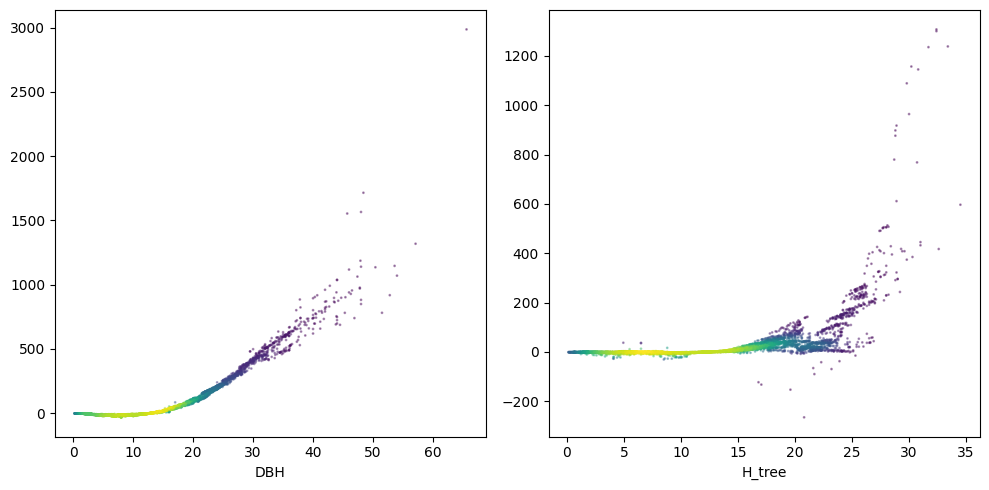

In [ ]:
# Execute and save matrix comparison distributions
autocontr = gradients_unscaled * all_fea_np * scaler.scale_
# print(type(var_names), var_names)
plt_contr_var(all_fea_raw, autocontr, list(var_names), save_fig=None)

slope_arr shape: (5555, 2)


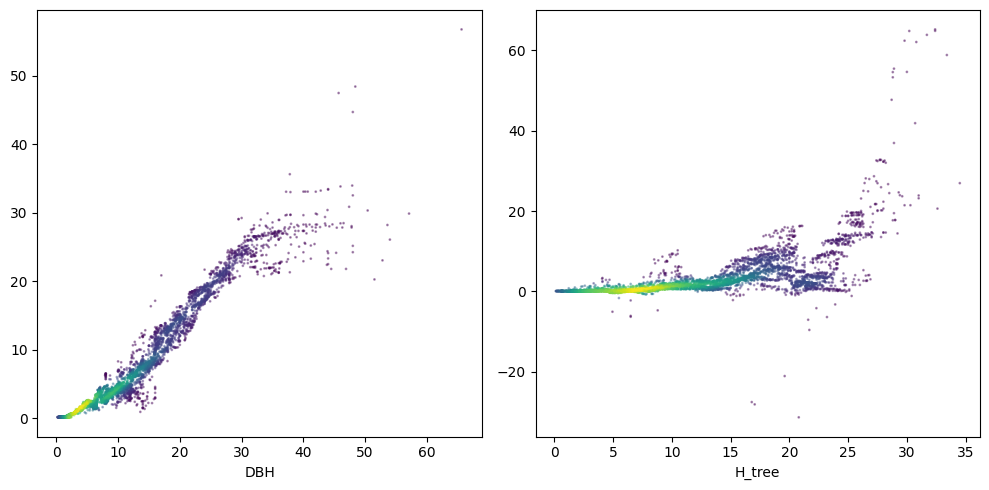

In [ ]:
plt_slope_var(all_fea_raw, gradients_unscaled, list(var_names), save_fig=None)

# 7. Outlier detection

---
We further exclude outliers for symbolic regression


In [ ]:
from sklearn.ensemble import IsolationForest

# data = np.column_stack((autocontr, gradients_unscaled))
data = np.column_stack((all_fea_raw[:, 0], autocontr[:, 0]))
# data = autocontr

# Initialize the model, expecting 10% outliers
model = IsolationForest(contamination=0.1, random_state=42)

# Fit and predict (returns 1 for inliers, -1 for outliers)
predictions = model.fit_predict(data)
np.save(os.path.join(SAVE_PATH, 'IsolationForest_filter.npy'), predictions)
fit_idx = (predictions==1) & (gradients_unscaled[:, 0] != 0) & (gradients_unscaled[:, 1] != 0) & (all_fea_raw[:, 0] < 25) # Here are the final data points for the symbolic regression.

contr_arr shape: (4879, 2)


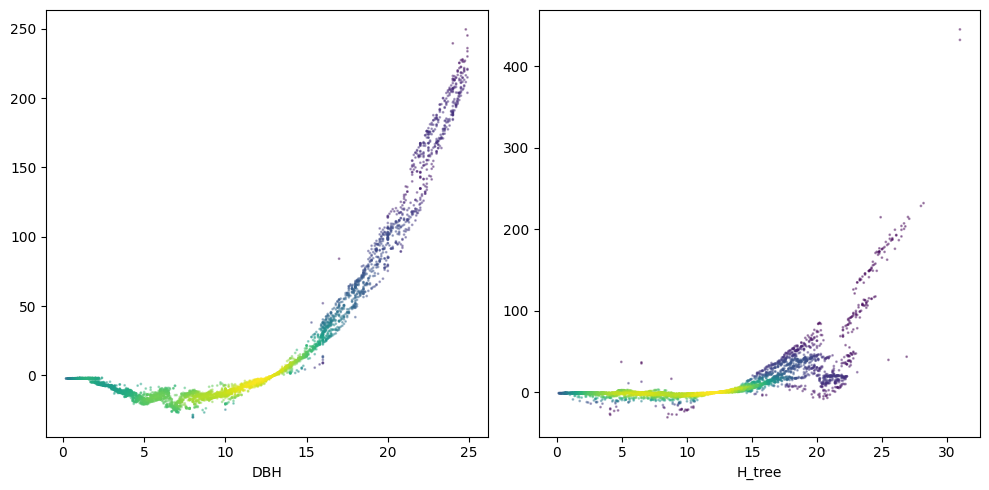

slope_arr shape: (4879, 2)


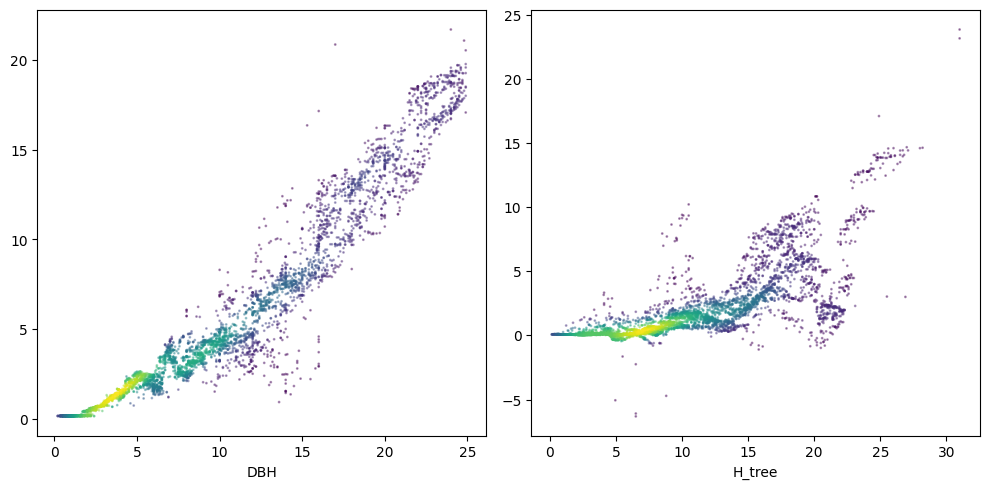

In [ ]:
###  Plot of the final training data  ###
plt_contr_var(all_fea_raw[fit_idx], autocontr[fit_idx], list(var_names), save_fig=None)
plt_slope_var(all_fea_raw[fit_idx], gradients_unscaled[fit_idx], list(var_names), save_fig=None)

## 8. Analytical Validation using Symbolic Regression

---
Distinct clustering in the training data suggests multiple potential functional forms for $\text{AGB} \sim \text{DBH} + \text{H}_{\text{tree}}$, though it could also due to DNN underfitting. To derive explicit equation models, we considered two options: (a) fitting separate equations to each individual cluster, or (2) fitting a single global equation to the entire training dataset to capture the overall driving mechanisms. We chose the global approach, as species-specific coefficient optimization can be applied later (similar to tranditional modeling). Furthermore, allowing the DNN to arbitrarily dictate cluster assignments undermines scientific interpretability.

In [ ]:
def preprocessing_sr(data_path:str, standerize=True,train_portion=0.8, min_train=3000):
    """Preprocessing the simulated data for symbolic regression.

    Args:
        dataset (array): orginal data
        pca (bool, optional): If conduct PCA (Principal component analysis) transformation. Defaults to True.
        standerize (bool, optional): If standerize X variables. Defaults to True.
        train_portion (float, optional): split training test data. Defaults to 0.8.
        min_train (int, optional): minimum number of training data. Defaults to 3000.
        nx (float, optional): random noise added to X (noise STD = nx * var_std). Defaults to 0.
        ny (float, optional): random noise added to Y (noise STD = ny * y_std). Defaults to 0.

    Returns:
        train_x (array): Preprocessed X training data
        train_y (array): Preprocessed Y training data
        test_x (array): Preprocessed X test data
        test_y (array): Preprocessed Y test data
        scaler (object): The standardization scaler (see sklearn.preprocessing.StandardScaler)
        pca_model (object): The PCA object (see sklearn.decomposition.PCA)
    """
    df_slope = np.load(os.path.join(data_path, 'autograd_unscaled.npy'))
    x_df = pd.read_csv(os.path.join(data_path, f'all_fea_raw.csv'))

    # fit_idx = (df_slope[:, 0] < 30) & (df_slope[:, 1] < 20)
    # fit_idx = fit_idx
    print(f"fit_idx: {np.sum(fit_idx)}")
    x_df = x_df.iloc[fit_idx]
    var_names = x_df.columns
    x_stack = x_df.to_numpy()
    print('x_stack.shape: ', x_stack.shape) # x_stack.shape:  (260388, 15)
    y_var = np.load(os.path.join(data_path, f'y_fea.npy'))[fit_idx]
    suf_idx = np.arange(x_stack.shape[0])
    np.random.shuffle(suf_idx)
    x_stack = x_stack[suf_idx, :]
    y_var = y_var[suf_idx]
    n_training = max(int(x_stack.shape[0] * train_portion), min_train)
    print('n_training: ', n_training)
    if standerize:
        scaler = joblib.load(os.path.join(data_path, "torch_scaler.bin"))
        x_stack = scaler.fit_transform(x_stack)

    else:
        scaler = None

    train_x = x_stack[:n_training, :].copy()
    train_y = y_var[:n_training].copy()

    test_x = x_stack[n_training:, :].copy()
    test_y = y_var[n_training:].copy()
    print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)
    return var_names, train_x, train_y, test_x, test_y, scaler


def fit_PySRRegressor(data_path: str, sub_folder: str, standerize=False, train_portion=0.1, min_train=200):
    var_names, train_x, train_y, _, _, _ = preprocessing_sr(data_path=data_path, standerize=standerize, train_portion=train_portion, min_train=min_train)
    df = pd.DataFrame(data=train_x, columns=var_names)
    if not os.path.exists(os.path.join(data_path, sub_folder)):
        os.makedirs(os.path.join(data_path, sub_folder))
    # print(train_x.shape, train_y.shape)
    df['response'] = train_y
    # print(df.head)

    dt_str = datetime.now().strftime("%Y%m%dT%H%M%S")
    # https://github.com/MilesCranmer/PySR/blob/master/pysr/sr.py
    model = PySRRegressor(
        niterations=200,  # < Increase me for better results; used 10000 in manuscript analysis, but it takes many hours to complete
        maxsize=30, # Max complexity of an equation.  Default is `20`.
        binary_operators=["+", "-", "*", "/", "^"], #
        unary_operators=[
            "exp",
            "log",
            # "sqrt",
        ],
        # temp_equation_file=True, #os.path.join(data_path, sub_folder, f"equation_{dt_str}.csv"), #  Where to save the files (.csv extension). Default is `None`.
        # tempdir=os.path.join(data_path, sub_folder), # directory for the temporary files.
        # delete_tempfiles=False,
        output_directory=os.path.join(data_path, sub_folder)
    )

    model.fit(df.drop(['response'], axis=1), df['response'])


def load_model(eq_path: str):
    return PySRRegressor.from_file(run_directory=eq_path) # model


def eval_eq_str_slope(model, eq_idx:int, df_x, df_slope, valid_idx, step=0.0001, slope_out=None)->float:
    # model = load_model(eq_path)
    # print(model.equations_.sympy_format[eq_idx])
    eq_slope = df_x.copy()
    loss_der = []
    for n in range(len(df_x.columns)):
        df_x.iloc[:, n] -= step
        pred_pre = model.predict(df_x, eq_idx)
        df_x.iloc[:, n] += 2 * step
        pred_pos = model.predict(df_x, eq_idx)
        df_x.iloc[:, n] -= step
        df_y = model.predict(df_x, eq_idx)
        # print(df_x.columns[n], sum(abs(pred_pre-df_y)), sum(abs(df_y-pred_pos)))
        if (sum(abs(pred_pre-df_y))!=0) | (sum(abs(df_y-pred_pos))!=0): #(sum(abs(pred_pre-pred_pos))!=0) |
            der = (pred_pos - pred_pre)/(2*step)
            eq_slope.iloc[:, n] = der
            diffs = der[valid_idx] - df_slope[valid_idx, n]
            rmse_der = np.sqrt(sum(diffs ** 2) / len(diffs)) / np.std(df_slope[valid_idx, n]) # np.std(df_x.iloc[:, n])
            # print(df_x.columns[n], rmse_der)
            # println(size(der), size(diffs), size(rmse_der), rmse_der)
            loss_der.append(rmse_der)
        else:
            eq_slope.iloc[:, n] *= 0
    if slope_out:
        eq_slope.to_csv(slope_out)
    # return rmse
    # print(model.equations_["equation"][eq_idx], loss_der)
    if len(loss_der) == 0:
        return None
    return sum(loss_der) /len(loss_der)


def eval_PySRRegressor(model_dir: str, sub_folder: str):
    # model_dir = os.path.join(SAVE_PATH, dnn_folder)
    # eq_files = glob(os.path.join(model_dir, sub_folder, "**", "hall_of_fame.csv"), recursive=True)
    eq_files = glob(os.path.join(model_dir, sub_folder, "*/"), recursive=True)
    if len(eq_files)==0:
        print(f"eval_PySRRegressor: No equation found in {model_dir} {sub_folder}")
        return

    df = pd.read_csv(os.path.join(model_dir, 'all_fea_raw.csv')).dropna()
    # df = df.drop(columns='y')
    print(df.head())
    df_slope = np.load(os.path.join(model_dir, 'autograd_unscaled.npy'))
    train_y = np.load(os.path.join(model_dir, 'y_fea.npy')).squeeze()
    dnn_pred = np.load(os.path.join(model_dir, 'predictions.npy')).flatten()
    # fit_idx = (df_slope[:, 0] < 30) & (df_slope[:, 1] < 20)
    # fit_idx = most_popular_index
    # df = df[fit_idx]
    # df_slope = df_slope[fit_idx, :]
    # train_y = train_y[fit_idx]
    print(df.iloc[fit_idx])
    print(df_slope[fit_idx, :])
    print(train_y[fit_idx])
    df.iloc[fit_idx].to_csv(os.path.join(SAVE_PATH, 'eval_PySRRegressor_test_input.csv'), index=False)
    model_eval = []
    for m in eq_files:
        # print(m)
        # eq_path = os.path.join(data_dir, m)
        model = load_model(m)
        # print(model.equations_)
        for i in range(len(model.equations_)):
            mad = np.mean(np.abs(model.predict(df, i) - train_y))
            rmse_std = np.sqrt(np.mean((model.predict(df, i) - train_y)**2)) / np.std(train_y)
            loss_partial = eval_eq_str_slope(model, i, df, df_slope, fit_idx)
            if loss_partial is None:
                model_eval.append({"model_path": m, "model_index": i, "Equation": model.equations_.sympy_format[i], "ADVISE_loss": None, "PySR_Score": model.equations_.score[i]})
            else:
                model_eval.append({"model_path": m, "model_index": i, "Equation": model.equations_.sympy_format[i], "ADVISE_loss": (loss_partial + rmse_std), "PySR_Score": model.equations_.score[i]})
            # print(eval_eq_str_slope(eq_path, i, df, train_y, df_slope))
    df_model_eval = pd.DataFrame(model_eval)
    # print("Summary df: \n", df.head(), "\n")
    df_model_eval.to_csv(os.path.join(model_dir, sub_folder, f"model_summary.csv"))

    # determine the percision of DNN model prediction. We will apply this precision threshold to round ADVISE_loss, preventing the selection of over-parameterized models that yield only marginal loss reductions.
    mad = np.min(np.abs((dnn_pred - train_y[:, 0])))
    fractional_part = f"{mad:f}".split('.')[1]
    precision_position = len(fractional_part) - len(fractional_part.lstrip('0')) + 1

    df_model_eval_sort = df_model_eval.sort_values(by='PySR_Score', ascending=False)
    max_score = df_model_eval_sort["PySR_Score"].idxmax()
    df_model_eval_sort['ADVISE_loss'] = df_model_eval_sort['ADVISE_loss'].round(precision_position)
    min_new = df_model_eval_sort["ADVISE_loss"].idxmin()
    with open(os.path.join(SAVE_PATH, "sym_model.txt"), "a") as file:
        org_model = load_model(df_model_eval_sort.loc[max_score]["model_path"]).equations_.sympy_format[df_model_eval_sort.loc[max_score]["model_index"]]
        new_model = load_model(df_model_eval_sort.loc[min_new]["model_path"]).equations_.sympy_format[df_model_eval_sort.loc[min_new]["model_index"]]
        file.writelines(f"Original, {org_model}\n")
        file.writelines(f"New, {new_model}\n")
    ## Validation ##
    org_pred = load_model(df_model_eval_sort.loc[max_score]["model_path"]).predict(df, df_model_eval_sort.loc[max_score]["model_index"])
    new_pred = load_model(df_model_eval_sort.loc[min_new]["model_path"]).predict(df, df_model_eval_sort.loc[min_new]["model_index"])
    org_slope_name = os.path.join(model_dir, sub_folder, f"org_symbolic_slope.csv")
    eval_eq_str_slope(load_model(df_model_eval_sort.loc[max_score]["model_path"]), df_model_eval_sort.loc[max_score]["model_index"], df, df_slope, fit_idx, slope_out=org_slope_name)
    new_slope_name = os.path.join(model_dir, sub_folder, f"new_symbolic_slope.csv")
    eval_eq_str_slope(load_model(df_model_eval_sort.loc[min_new]["model_path"]), df_model_eval_sort.loc[min_new]["model_index"], df, df_slope, fit_idx, slope_out=new_slope_name)
    sym_org_rmse = np.sqrt(np.mean(np.square(train_y - org_pred)))
    sym_new_rmse = np.sqrt(np.mean(np.square(train_y - new_pred)))
    # dnn_pred = np.load(os.path.join(model_dir, "predictions.npy")).flatten()# [fit_idx]
    dnn_rmse = np.sqrt(np.mean(np.square(train_y - dnn_pred))) #.values.flatten()
    print(f"pySR_Sym RMSE:", sym_org_rmse, " ADVISE_Sym RMSE:", sym_new_rmse, " DNN RMSE:", dnn_rmse)
    pd.DataFrame({"DNN_true": train_y, "DNN_pred": dnn_pred, "Sym_pySR": org_pred, "Sym_ADVISE": new_pred, "Sym_idx": fit_idx}).to_csv(os.path.join(model_dir, sub_folder, f"Prediction_compare.csv"))



def extract_final_eq(model_dir: str, sub_folder: str):
    df = pd.DataFrame(columns=["pySR", "ADVISE"])
    model_dir = os.path.join(model_dir, sub_folder, f"model_summary.csv")
    if not os.path.exists(model_dir):
        print(f"extract_final_eq: No model found in {model_dir}")
        return
    df_model = pd.read_csv(model_dir)
    max_score = df_model["PySR_Score"].idxmax()
    min_new = df_model["ADVISE_loss"].idxmin()
    org_model = df_model.loc[max_score]["Equation"]
    new_model = df_model.loc[min_new]["Equation"]
    rec = pd.DataFrame([{"pySR": org_model, "ADVISE": new_model}])
    df = pd.concat([df, rec], ignore_index=True)
    df.to_csv(os.path.join(os.path.dirname(model_dir), "final_eq.csv"), index=False)
    return df

## 9. Equation model evaluation


---
We ran the symbolic regression on HPC for longer time. The final ADVISE selected equation is:

Below, we compares the predition between DNN model, symbolic default selected model and ADVISE selected model.


/tmp/ipykernel_1063/4038924264.py:12: RuntimeWarning: invalid value encountered in power
  return a * b**x[:, 1] + c * x[:, 0]**d * (x[:, 1] + e)
/tmp/ipykernel_1063/4038924264.py:27: RuntimeWarning: invalid value encountered in log
  return np.exp(a + b * np.log(c * x[:, 0]**2 * x[:, 1]))


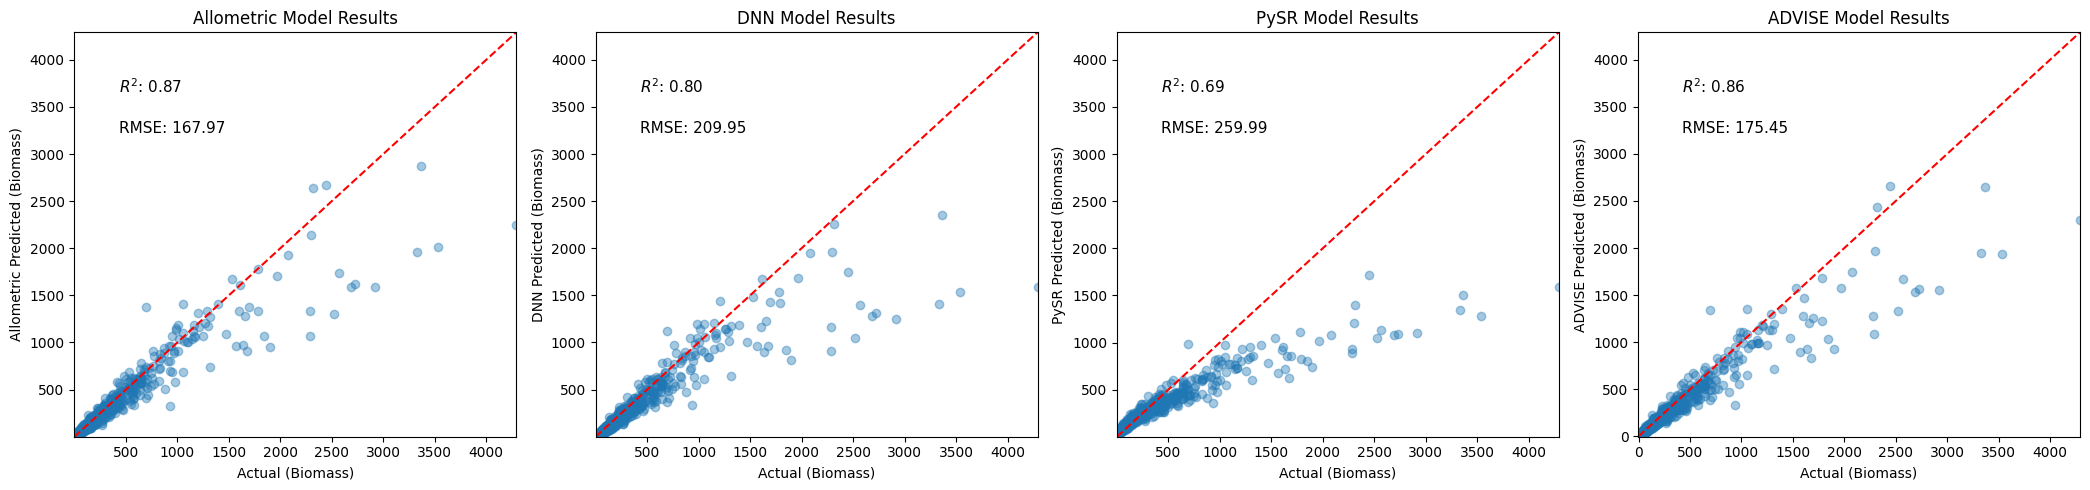

In [ ]:
from scipy.optimize import curve_fit

# =============================================================================
# Define Model Functions
# =============================================================================

def advise_function(x, a, b, c, d, e):
    """
    ADVISE biomass prediction function.
    Original: 0.010246243*1.3361187**H_tree + 0.010246243*DBH**2.0500562*(H_tree + 10.123182)
    """
    return a * b**x[:, 1] + c * x[:, 0]**d * (x[:, 1] + e)


def pysr_function(x, a):
    """
    PySR biomass prediction function.
    Original: DBH**1.6434433
    """
    return x[:, 0]**a

def Allometric_function(x, a, b, c):
    """
    Allometric biomass model.
    Original: exp(a + b * ln(c * DBH**2 * H_tree))
    """
    return np.exp(a + b * np.log(c * x[:, 0]**2 * x[:, 1]))


# =============================================================================
# Load Validation Data
# =============================================================================

dataset_valid = pd.read_csv(VALID_PATH)[["DBH", "H_tree", "Pabo"]]
x_valid = dataset_valid[["DBH", "H_tree"]].to_numpy()
y_valid = dataset_valid["Pabo"].to_numpy()


# =============================================================================
# Perform Regression Fits
# =============================================================================

advise_opt, advise_cov = curve_fit(
    advise_function,
    scaler.inverse_transform(train_x_np),
    train_y_np
)
pysr_opt, pysr_cov = curve_fit(
    pysr_function,
    scaler.inverse_transform(train_x_np),
    train_y_np
)
Allometric_opt, Allometric_cov = curve_fit(
    Allometric_function,
    scaler.inverse_transform(train_x_np),
    train_y_np
)

# =============================================================================
# Function for Plotting
# =============================================================================

def plot_model_comparison(ax, y_valid, y_pred, model_name):
    """Create a diagnostic scatter plot comparing actual vs predicted values."""
    # Calculate metrics
    r_squared = r2_score(y_valid, y_pred)
    rmse = np.sqrt(np.mean((y_valid - y_pred)**2))

    # Determine axis limits
    val_max = max(np.max(y_valid), np.max(y_pred))
    val_min = min(np.min(y_valid), np.min(y_pred))

    # Create scatter plot
    ax.scatter(y_valid, y_pred, alpha=0.4)
    ax.plot([y_valid.min(), y_valid.max()],
            [y_valid.min(), y_valid.max()],
            'r--', label="1:1 line")

    # Add annotations
    bbox_props = dict(facecolor='white', alpha=0.3, edgecolor='none')
    ax.annotate(f"$R^2$: {r_squared:.2f}",
                xy=(0.1, 0.85), xycoords='axes fraction',
                fontsize=11, bbox=bbox_props)
    ax.annotate(f"RMSE: {rmse:.2f}",
                xy=(0.1, 0.75), xycoords='axes fraction',
                fontsize=11, bbox=bbox_props)

    # Set labels and limits
    ax.set_xlabel('Actual (Biomass)')
    ax.set_ylabel(f'{model_name} Predicted (Biomass)')
    ax.set_xlim(val_min, val_max)
    ax.set_ylim(val_min, val_max)
    ax.set_title(f'{model_name} Model Results')


# =============================================================================
# Generate Model Predictions and Visualizations
# =============================================================================

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(21, 5))

# --- Established Model ---
y_pred_pysr = Allometric_function(x_valid, *Allometric_opt)
plot_model_comparison(axs[0], y_valid, y_pred_pysr, 'Allometric')

# --- DNN Model ---
input_valid = torch.from_numpy(scaler.transform(x_valid)).float()
input_valid = input_valid.clone().detach().requires_grad_(True)
predictions = final_model(input_valid)
y_pred_dnn = predictions.detach().numpy().squeeze()
plot_model_comparison(axs[1], y_valid, y_pred_dnn, 'DNN')

# --- PySR Model ---
y_pred_pysr = pysr_function(x_valid, *pysr_opt)
plot_model_comparison(axs[2], y_valid, y_pred_pysr, 'PySR')

# --- ADVISE Model ---
y_pred_advise = advise_function(x_valid, *advise_opt)
plot_model_comparison(axs[3], y_valid, y_pred_advise, 'ADVISE')

plt.tight_layout()
plt.show()